<a href="https://colab.research.google.com/github/Amruda-glitch/Hands-on-Training/blob/main/AI_HoS_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/preprocessing_dataset.csv')

In [ ]:
df1=df.copy()
df2=df.copy()

In [ ]:
df.head()

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [ ]:
df.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [ ]:
df.shape

(10, 5)

Finding missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [ ]:
df.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [ ]:
df.isnull()

,Name,Age,Gender,Salary,Department
0,False,False,False,False,False
1,False,False,False,False,False
2,False,True,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,True,False,False
6,False,False,False,True,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


In [ ]:
df.isna()

,Name,Age,Gender,Salary,Department
0,False,False,False,False,False
1,False,False,False,False,False
2,False,True,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,True,False,False
6,False,False,False,True,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


To identify the missing values in the data (features) through graphical representation. - **missingno**

<Axes: >

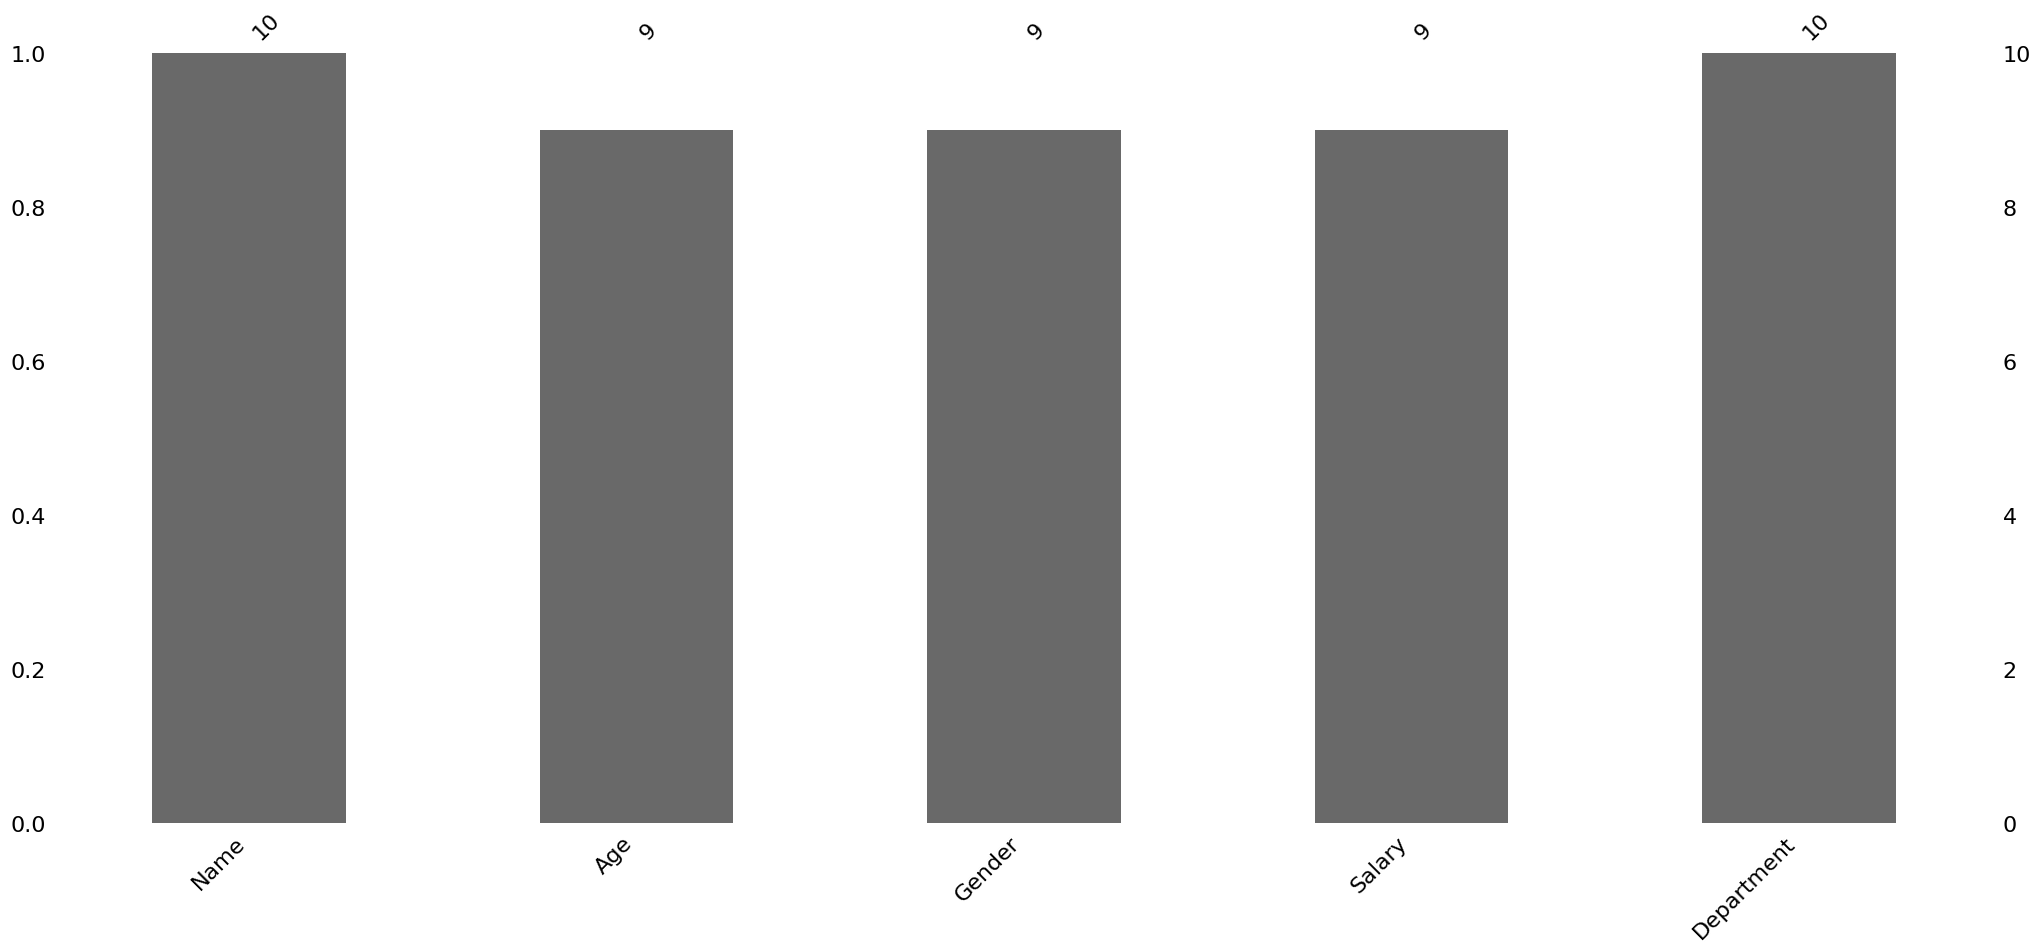

In [ ]:
import missingno as msno
msno.bar(df)

<Axes: >

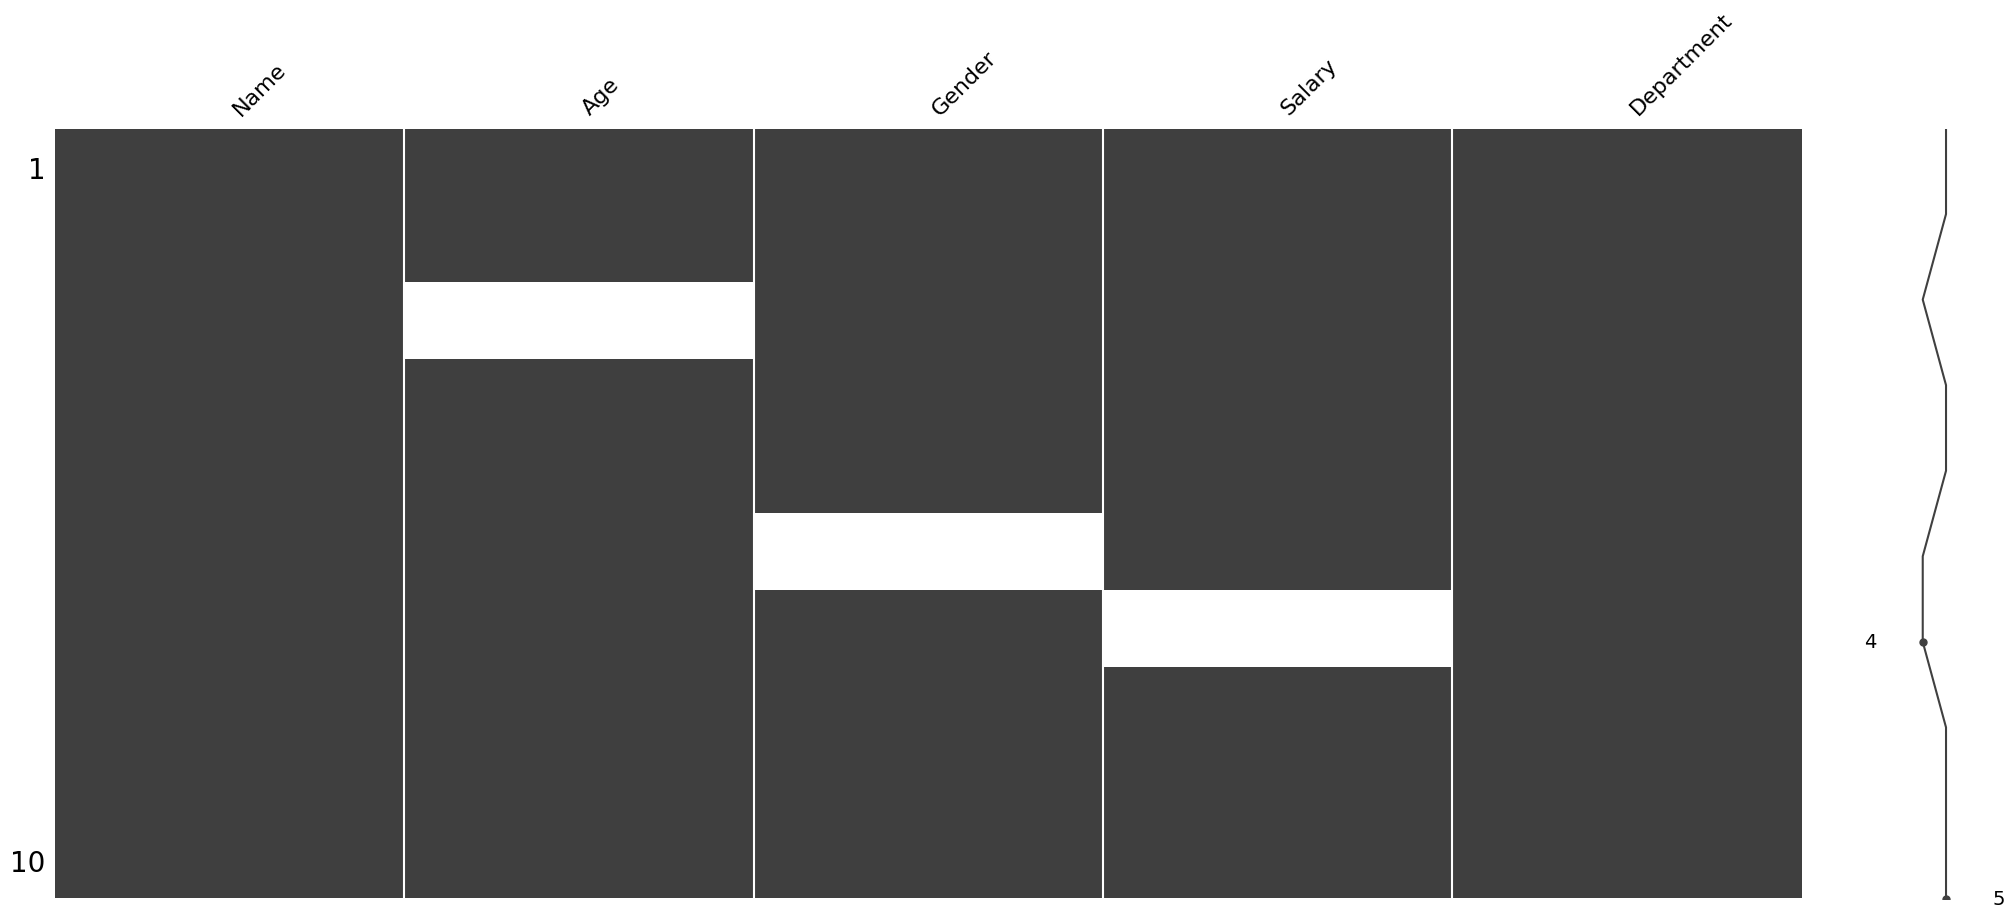

In [ ]:
msno.matrix(df)

<Axes: >

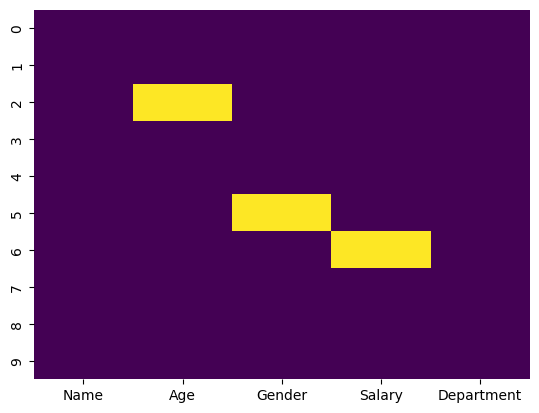

In [ ]:
sns.heatmap(df.isnull(),cbar=False, cmap='viridis')

Handling Missing Values

In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
'''df['Age']= df['Age'].fillna(df['Age'].mean())'''
df['Salary'].fillna(df['Salary'].mean(),inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
'''mode()[0] - represents the most frequent value filled in the 0th index i.e, first position and replaces it.'''

/tmp/ipykernel_8265/664994249.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/tmp/ipykernel_8265/664994249.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

**Simple Imputer**

In [38]:
from sklearn.impute import SimpleImputer

In [39]:
imp=SimpleImputer(strategy='median')
imp1=SimpleImputer(strategy='most_frequent')

In [40]:
df1[['Age']]=imp.fit_transform(df1[['Age']])
df1[['Salary']]=imp.fit_transform(df1[['Salary']])

In [41]:
df1[["Gender"]] = imp1.fit_transform(df1[["Gender"]])

Finding Outliers

<Axes: ylabel='Age'>

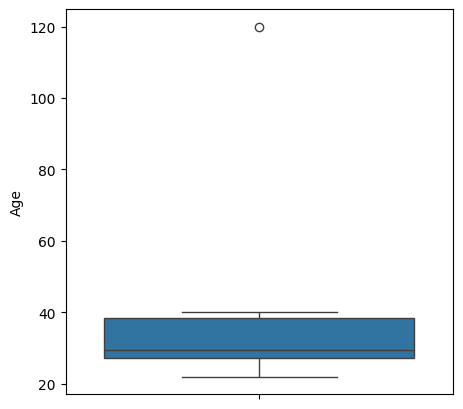

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(df2['Age'])

<Axes: ylabel='Salary'>

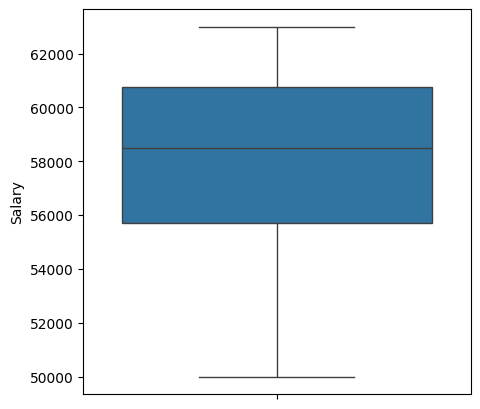

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(df2['Salary'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
df2['Gender']= enc.fit_transform(df2['Gender'])

<Axes: ylabel='Gender'>

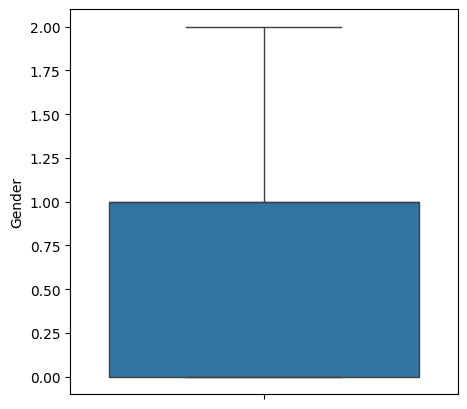

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(df2['Gender'])

In [ ]:
Q1=df2['Age'].quantile(0.25)
Q3=df2['Age'].quantile(0.75)
IQR=Q3-Q1

lb=Q1-1.5*IQR
ub=Q3+1.5*IQR

outlier= df2[(df2['Age']<lb)|(df2['Age']>ub)]
print(outlier)


    Name    Age  Gender  Salary Department
6  Grace  120.0       0     NaN    Finance


In [43]:
from scipy.stats import zscore
z_scores=zscore(df1['Age'])
df1[np.abs(z_scores)>2.5]

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,59000.0,Finance


In [51]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.1)
df['outlier']=iso.fit_predict(df[['Age','Salary']])
df[df['outlier']==-1]

,Name,Age,Gender,Salary,Department,outlier
6,Grace,120.0,F,NaN,Finance,-1
